<a href="https://colab.research.google.com/github/gaelBZH/NumericalMethods/blob/main/Laboratory_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Numerical Methods - Laboratory 2
### Gaël KERNINON (Erasmus Student)

## Exercise 1


#### a. Calculating number of possible numbers.
- k (1 bit), so $k \in \{0, 1\}$
- $d_1d_2$ (2 bits), so  $d_1d_2 \in \{00, 01, 10, 11\}$
- e is 2 bits (0, 1, 2 or 3), so $e-1 \in \{-1, 0, 1, 2\}$

By calculating, we have $2 \times 4 \times 4 = 32$ possible real numbers represented in this system.
That said, the value 0 occurrs twice. So, there are 31 distinct values possible. 


#### b. Calculating Maximum Number.
The maximum number is positive ($k=0$), mantissa is $m=0.11_2 = 0.75_{10}$ and $e = 11_2 = 3_{10}$, so we have :
$$
rd(x)_{maximum} = (-1)^0 \times 0.75 \times 2^{(3-1)} = 3.0
$$
The same way, the minimum number is **-3.0**.


#### c. Calculating smallest positive number
The smallest positive number is, of course, positive ($k=0$), mantissa is $m = 0.01_2 = 0.25_{10}$ and $e=0$, so we have :
$$
rd(x)_{minimum} = (-1)^0 \times 0.25 \times 2^{(0-1)} = 0.125
$$
The same way, the biggest negative number is **-0.125**.



## Exercise 2


In [2]:
import numpy as np

def exercise_2(precision, p):
    n = 0
    while True:
        epsilon = precision(1 / 2**n)
        if precision(1.0) + epsilon == precision(1.0):
            print(f"Precision float{p} : n={n} and epsilon = 1/2**{n}")
            break
        n += 1

exercise_2(np.float16, 16)
exercise_2(np.float32, 32)
exercise_2(np.float64, 64)
# exercise_2(np.float128, 128) does not exist (!)

Precision float16 : n=11 and epsilon = 1/2**11
Precision float32 : n=24 and epsilon = 1/2**24
Precision float64 : n=53 and epsilon = 1/2**53


## Exercise 3

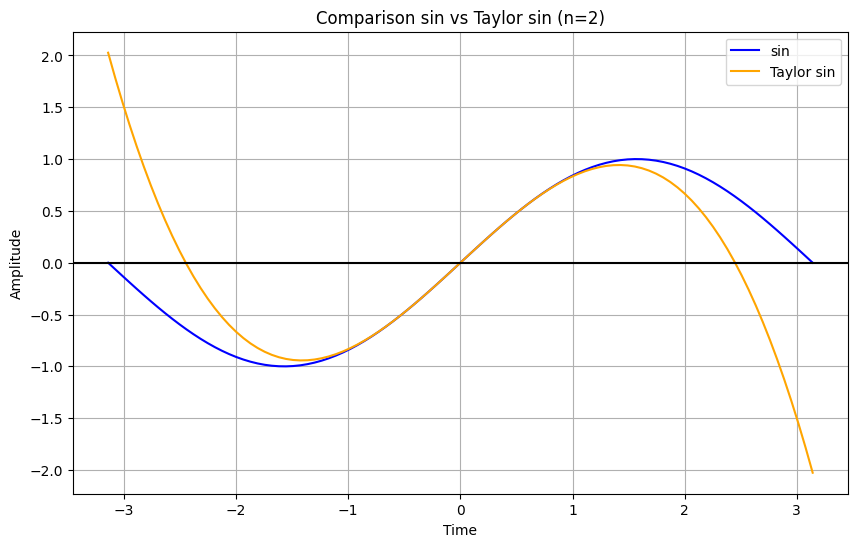

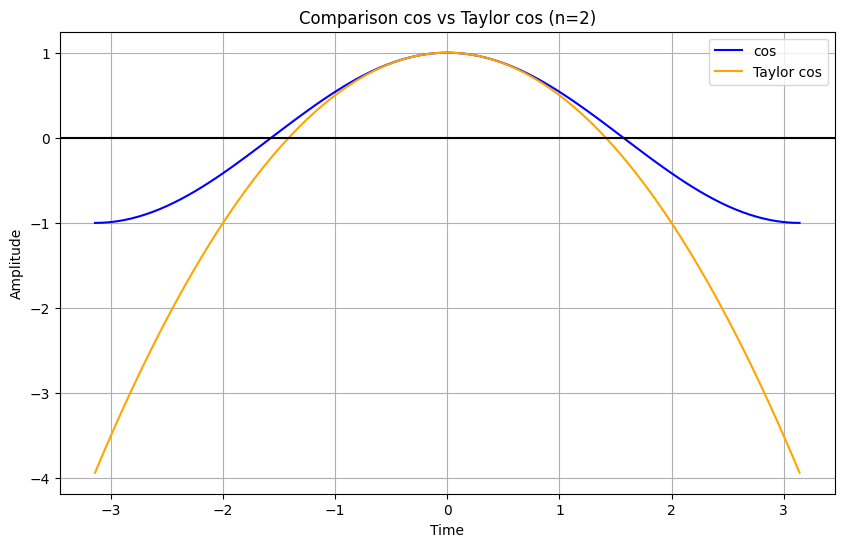

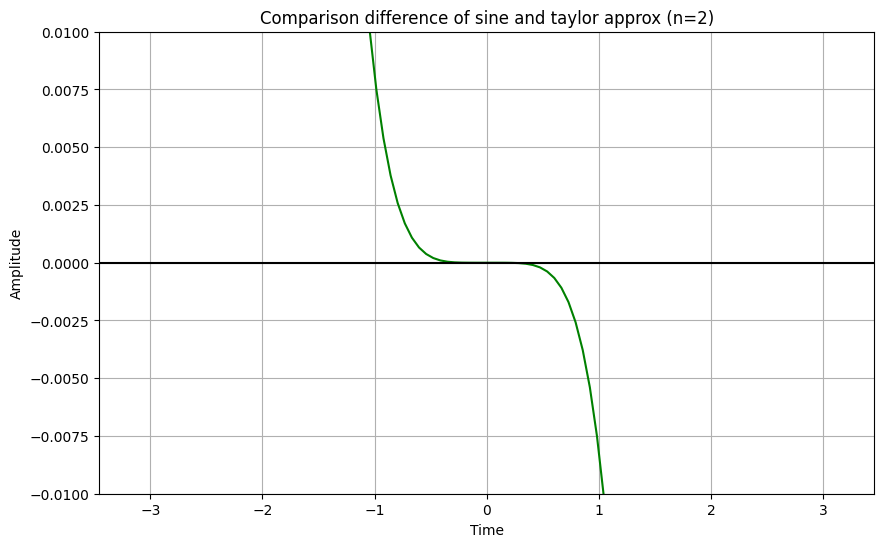

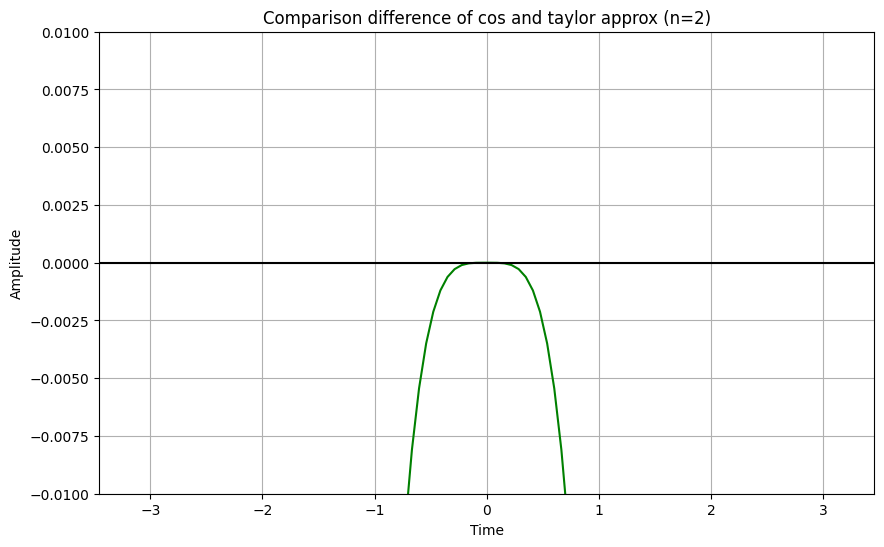

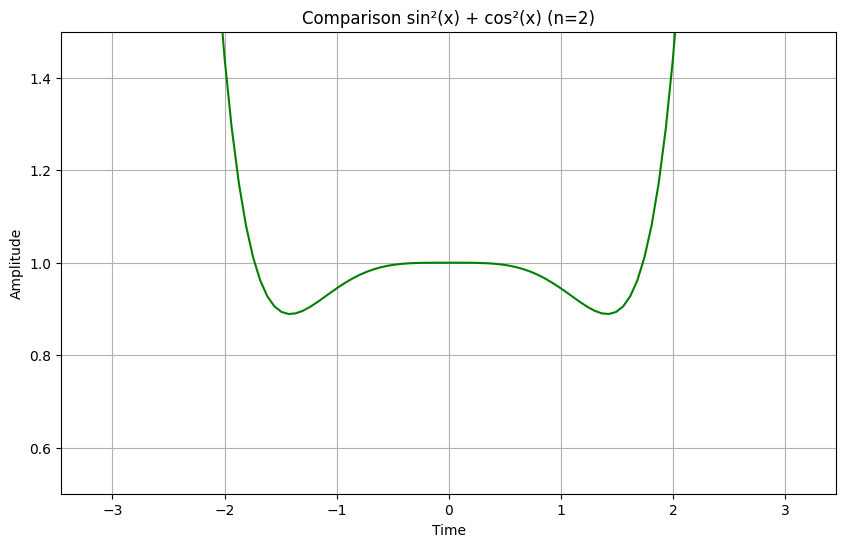

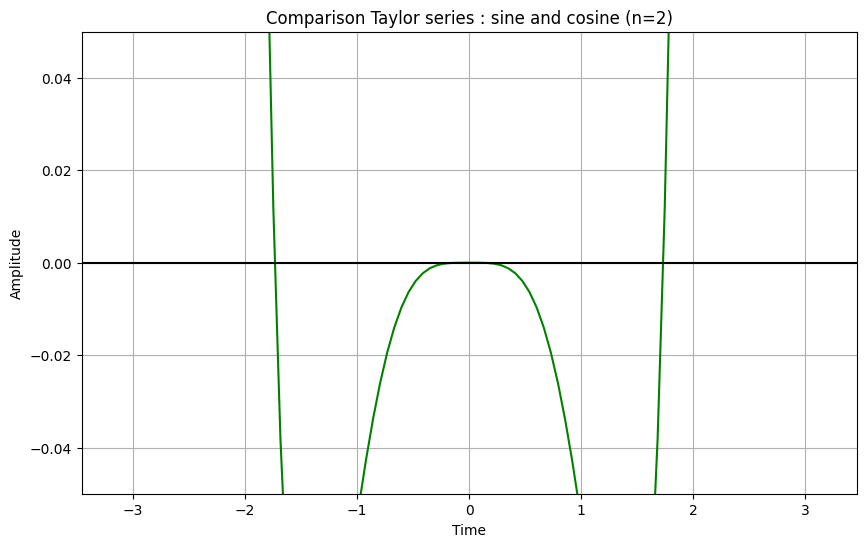

In [3]:
import numpy as np
import matplotlib.pyplot as plot
import math

# Taylor Approximations Functions
def taylor_sin(x, n):
    res = 0
    for i in range(n):
        res += ((-1)**i * x**(2*i + 1)) / math.factorial(2*i + 1)
    return res

def taylor_cos(x, n):
    res = 0
    for i in range(n):
        res += ((-1)**i * x**(2*i)) / math.factorial(2*i)
    return res



# Printint (Plotting) functions
def print_comparison(f1, f2, namef1, namef2, n=5, color_a="blue", color_b="orange"):
    x = np.linspace(-np.pi, np.pi, 100)

    plot.figure(figsize=(10, 6))

    plot.plot(x, f1(x), label=namef1, color=color_a)
    plot.plot(x, f2(x, n), label=namef2, color=color_b)

    plot.title(f'Comparison {namef1} vs {namef2} (n={n})')
    plot.xlabel('Time')
    plot.ylabel('Amplitude')
    plot.grid(True, which='both')
    plot.axhline(y=0, color='k')
    plot.legend() # add a legend

    plot.show()

def print_function(f, name, n=5, color="green", y_axis_scale=0):
    x = np.linspace(-np.pi, np.pi, 100)

    plot.figure(figsize=(10, 6))

    plot.plot(x, f(x, n), label=name, color=color)

    plot.title(f'Comparison {name} (n={n})')
    plot.xlabel('Time')
    plot.ylabel('Amplitude')
    plot.grid(True, which='both')
    plot.axhline(y=0, color='k')

    if y_axis_scale == 1:
        plot.ylim(-0.01, 0.01)
    elif y_axis_scale == 2:
        plot.ylim(-0.05, 0.05)
    else:
        plot.ylim(0.5, 1.5)

    plot.show()



# Difference Functions and Formulas
def diff_sin(x, n):
    return taylor_sin(x, n) - np.sin(x)

def diff_cos(x, n):
    return taylor_cos(x, n) - np.cos(x)

def formula(x, n):
    # sin²(x) + cos²(x)
    return taylor_sin(x, n)**2 + taylor_cos(x, n)**2

def formula2(x, n):
    # sin²(x) + cos²(x) - 1
    return taylor_sin(x, n)**2 + taylor_cos(x, n)**2 - 1


# Main Programm
print_comparison(np.sin, taylor_sin, "sin", "Taylor sin", n=2)
print_comparison(np.cos, taylor_cos, "cos", "Taylor cos", n=2)
print_function(diff_sin, "difference of sine and taylor approx", n=2, y_axis_scale=1)
print_function(diff_cos, "difference of cos and taylor approx" , n=2, y_axis_scale=1)
print_function(formula, "sin²(x) + cos²(x)", n=2)
print_function(formula2, "Taylor series : sine and cosine", n=2, y_axis_scale=2)
